In [3]:
import json
import cv2
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# --- 1. SET ROOT TO PROJECT DIRECTORY (OilSpill_SIH) ---
# .parent moves up from 'notebooks/' to 'OilSpill_SIH/'
PROJECT_ROOT = Path().resolve().parent 

VAL_IMG_DIR = PROJECT_ROOT / "data" / "satellite" / "images" / "images" / "val"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "spill"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Looking for images in:", VAL_IMG_DIR)

# --- 2. FIND IMAGES (WITH SANITY CHECK) ---
image_paths = sorted(list(VAL_IMG_DIR.glob("*.png")))

# If val is empty or you want to process train images instead, fallback:
if len(image_paths) == 0:
    TRAIN_IMG_DIR = PROJECT_ROOT / "data" / "satellite" / "images" / "images" / "train"
    image_paths = sorted(list(TRAIN_IMG_DIR.glob("*.png")))
    print(f"Val was empty, switched to train: Found {len(image_paths)} images.")
else:
    print(f"Found {len(image_paths)} validation images.")

assert len(image_paths) > 0, "No images found! Check that the path to images/train or val exists."

# --- 3. MODEL SETUP ---
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

# Model weights are inside the current notebooks directory
weights_path = Path().resolve() / "best_oil_spill_unet.pth"
model.load_state_dict(torch.load(str(weights_path), map_location=device))
model.eval()

infer_transform = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

def pixel_to_geo(x, y, bounds, width=256, height=256):
    min_lon, min_lat, max_lon, max_lat = bounds
    lon = min_lon + (x / width) * (max_lon - min_lon)
    lat = max_lat - (y / height) * (max_lat - min_lat)
    return [round(lon, 6), round(lat, 6)]

geo_bounds = (72.5000, 18.8000, 72.8500, 19.1500)

# --- 4. RUN BATCH ---
all_metadata_records = []

for img_path in tqdm(image_paths):
    img_id = img_path.stem
    
    # 1. Read SAR Image
    raw_img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if raw_img is None:
        continue
    h, w = raw_img.shape

    # 2. Run Inference
    tensor_input = infer_transform(image=raw_img)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor_input)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    binary_mask = (probs > 0.5).astype(np.uint8)

    # 3. Contour extraction
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_contours = [c for c in contours if cv2.contourArea(c) >= 30]

    detected = len(valid_contours) > 0
    confidence = 0.0
    bbox_result = []
    geojson_features = []

    if detected:
        confidence = round(float(np.mean(probs[binary_mask == 1])), 2)

        largest_c = max(valid_contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(largest_c)
        bbox_result = [int(x), int(y), int(x + bw), int(y + bh)]

        for c in valid_contours:
            epsilon = 0.005 * cv2.arcLength(c, True)
            approx = cv2.approxPolyDP(c, epsilon, True)
            poly = [pixel_to_geo(pt[0][0], pt[0][1], geo_bounds, w, h) for pt in approx]
            if len(poly) >= 3:
                poly.append(poly[0])  # Close ring
                geojson_features.append({
                    "type": "Feature",
                    "properties": {"spill_id": img_id, "confidence": confidence},
                    "geometry": {"type": "Polygon", "coordinates": [poly]}
                })

    # 4. Save Mask Image to outputs/spill/
    mask_rel_path = f"outputs/spill/{img_id}_mask.png"
    cv2.imwrite(str(PROJECT_ROOT / mask_rel_path), binary_mask * 255)

    # 5. Save GeoJSON to outputs/spill/
    geojson_path = OUTPUT_DIR / f"{img_id}.geojson"
    with open(geojson_path, "w") as f:
        json.dump({"type": "FeatureCollection", "features": geojson_features}, f, indent=2)

    # 6. Save Exact 5-Key Contract to outputs/spill/
    api_contract = {
        "image_id": img_id,
        "detected": detected,
        "confidence": confidence,
        "mask_path": mask_rel_path,
        "bbox": bbox_result
    }

    with open(OUTPUT_DIR / f"{img_id}.json", "w") as f:
        json.dump(api_contract, f, indent=2)

    all_metadata_records.append(api_contract)

# 7. Save Consolidated Master List to outputs/spill/
with open(OUTPUT_DIR / "all_detections.json", "w") as f:
    json.dump(all_metadata_records, f, indent=2)

print(f"\nDone! Successfully processed {len(all_metadata_records)} images into {OUTPUT_DIR}")

Project Root: /Users/ava/OilSpill_SIH
Looking for images in: /Users/ava/OilSpill_SIH/data/satellite/images/images/val
Found 1615 validation images.


100%|███████████████████████████████████████| 1615/1615 [00:37<00:00, 42.84it/s]


Done! Successfully processed 1615 images into /Users/ava/OilSpill_SIH/outputs/spill


In [2]:
import json

with open("../outputs/spill/all_detections.json") as f:
    records = json.load(f)

# Sort by confidence score (highest confidence first)
true_positives = [r for r in records if r["detected"]]
true_positives.sort(key=lambda x: x["confidence"], reverse=True)

# Collect negative / clean water cases
negatives = [r for r in records if not r["detected"]]

print(f"Top 5 showcase spills (highest confidence):")
for item in true_positives[:5]:
    print(f"  ID: {item['image_id']} | Confidence: {item['confidence']} | BBox: {item['bbox']}")

print(f"\nClean sea samples (for negative testing):")
for item in negatives[:5]:
    print(f"  ID: {item['image_id']} | Detected: False")

Top 5 showcase spills (highest confidence):
  ID: sentinel_11 | Confidence: 1.0 | BBox: [0, 0, 256, 256]
  ID: sentinel_155 | Confidence: 1.0 | BBox: [0, 0, 256, 256]
  ID: sentinel_354 | Confidence: 1.0 | BBox: [0, 0, 256, 256]
  ID: sentinel_440 | Confidence: 1.0 | BBox: [0, 0, 256, 256]
  ID: sentinel_455 | Confidence: 1.0 | BBox: [0, 0, 256, 256]

Clean sea samples (for negative testing):
  ID: palsar_117 | Detected: False
  ID: palsar_13 | Detected: False
  ID: palsar_140 | Detected: False
  ID: palsar_166 | Detected: False
  ID: palsar_174 | Detected: False


Plotting showcase sample: palsar_0 (Confidence: 0.86)


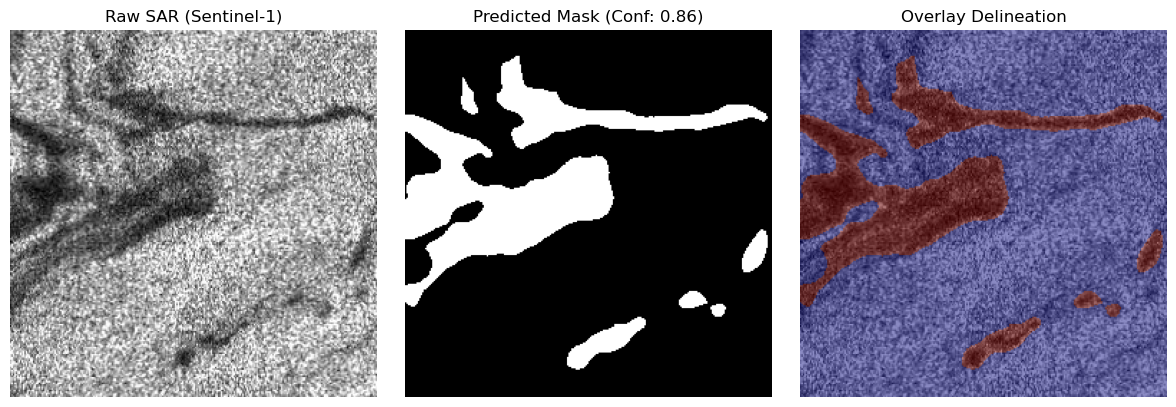

Comparison preview saved to: /Users/ava/OilSpill_SIH/docs/model_prediction_sample.png


In [4]:
import json
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Resolve project root
PROJECT_ROOT = Path().resolve().parent

# 2. Find a high-confidence spill from your generated catalog
with open(PROJECT_ROOT / "outputs" / "spill" / "all_detections.json") as f:
    detections = json.load(f)

# Pick the first detected spill
sample = next(d for d in detections if d["detected"])
sample_id = sample["image_id"]
print(f"Plotting showcase sample: {sample_id} (Confidence: {sample['confidence']})")

# 3. Load the SAR image and predicted mask
sar_path = PROJECT_ROOT / "data" / "satellite" / "images" / "images" / "val" / f"{sample_id}.png"
if not sar_path.exists():
    sar_path = PROJECT_ROOT / "data" / "satellite" / "images" / "images" / "train" / f"{sample_id}.png"

mask_path = PROJECT_ROOT / "outputs" / "spill" / f"{sample_id}_mask.png"

raw_img = cv2.imread(str(sar_path), cv2.IMREAD_GRAYSCALE)
binary_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

# 4. Plot side-by-side comparison
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(raw_img, cmap="gray")
ax[0].set_title("Raw SAR (Sentinel-1)")

ax[1].imshow(binary_mask, cmap="gray")
ax[1].set_title(f"Predicted Mask (Conf: {sample['confidence']})")

ax[2].imshow(raw_img, cmap="gray")
ax[2].imshow(binary_mask, cmap="jet", alpha=0.45)
ax[2].set_title("Overlay Delineation")

for a in ax:
    a.axis("off")

plt.tight_layout()

# 5. Save to docs for your team README / presentation
docs_dir = PROJECT_ROOT / "docs"
docs_dir.mkdir(parents=True, exist_ok=True)
save_path = docs_dir / "model_prediction_sample.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Comparison preview saved to: {save_path}")